[*] 수평/수직 텐서 추출 및 시간축 정규화를 시작합니다...

[+] 수평(H) 및 수직(V) 텐서 스토어 적재 완료.
[+] 32-Panel 대시보드 저장 완료: ..\..\img\visualization\spectrograms\Combined_32_Panels_Dashboard.png

[*] Difference Map (MCI vs HC) 연산 및 시각화를 시작합니다...


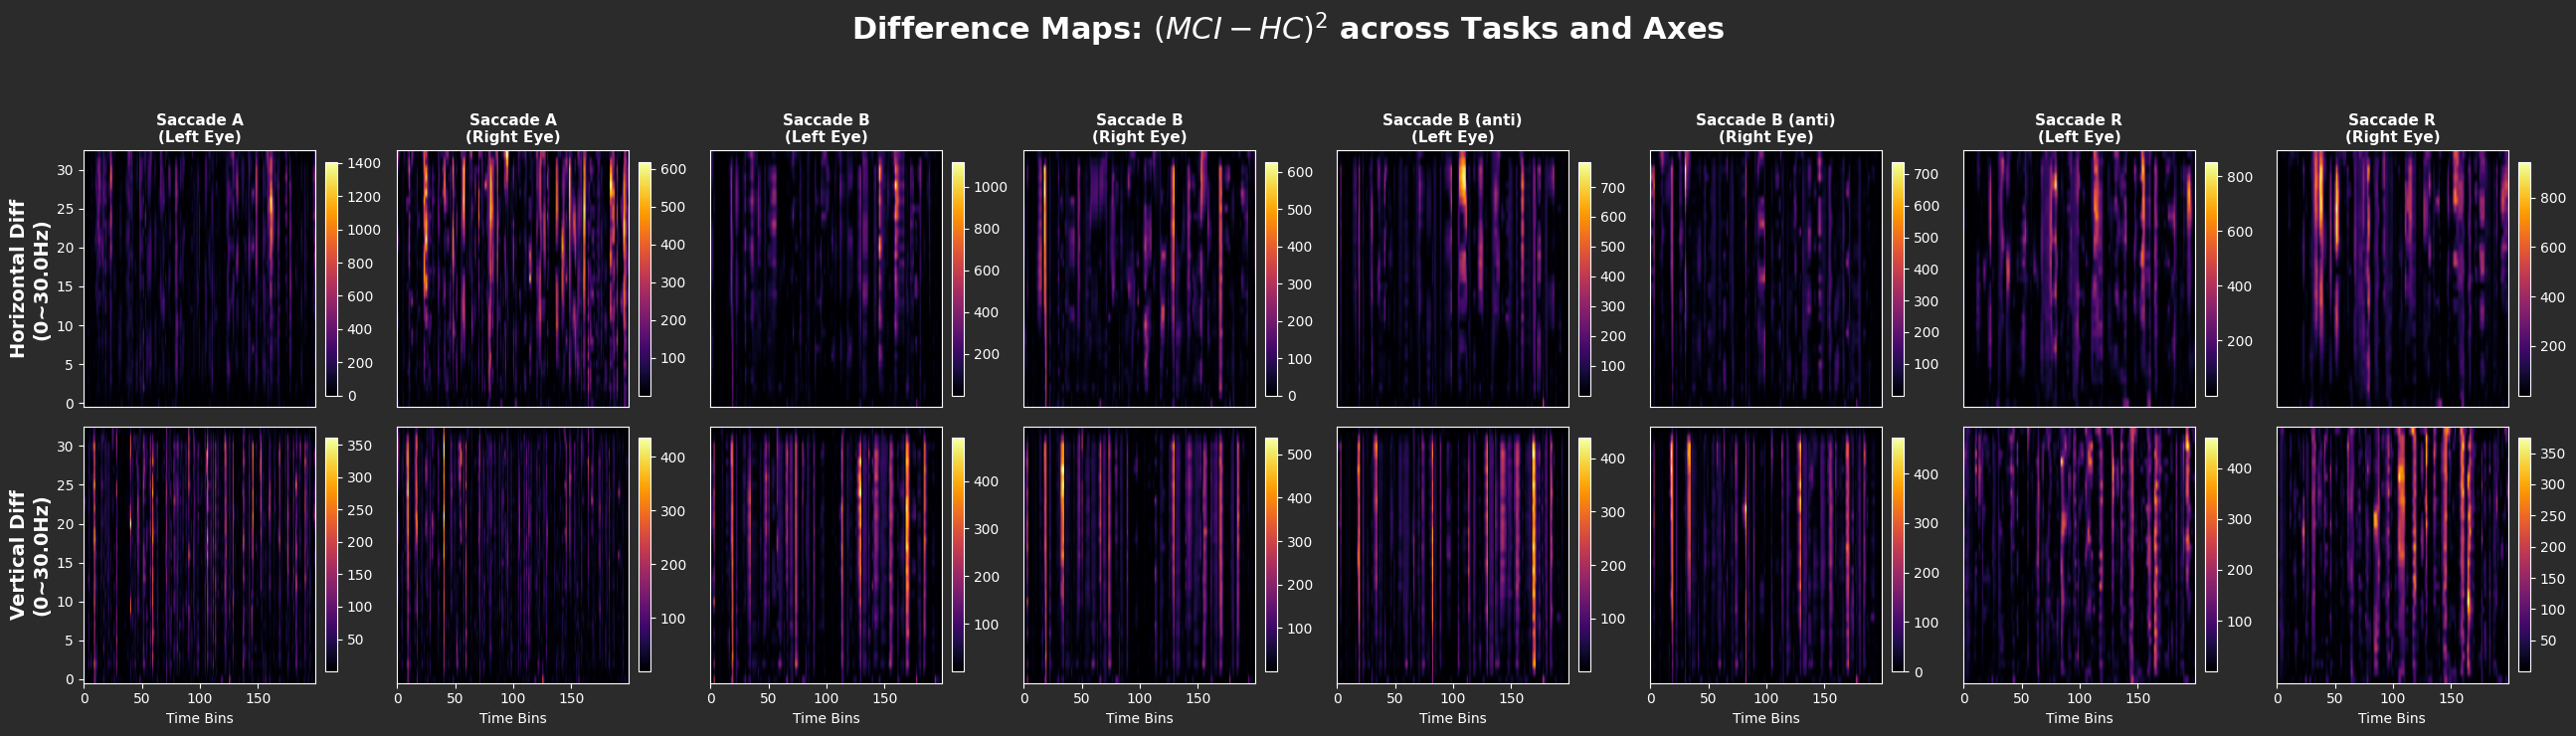

[+] Difference Map 대시보드 저장 완료: ..\..\img\visualization\difference_maps\16_size\Combined_Difference_Maps_Squared.png


In [2]:
# %% [markdown]
# # Group Mean Spectrogram Aggregator (HC vs MCI) - Step 1: Difference Map Edition
# 기존의 통계 추출 및 32-Panel 통합 대시보드 기능에 더하여,
# 04/10 교수님 피드백을 반영한 `(MCI - HC)^2` 기반의 디퍼런스 맵(Difference Map) 시각화 레이어를 추가했습니다.

# %%
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from scipy import signal
from scipy.ndimage import zoom
from collections import defaultdict

class MeanSpectrogramAggregator:
    def __init__(self, target_time_bins=200, nperseg=128, noverlap=None, fs=120.0, target_fs=60.0, min_freq=0.0, max_freq=None, dynamic_fs=False):
        self.target_time_bins = target_time_bins
        self.nperseg = nperseg
        self.noverlap = noverlap
        self.default_fs = fs
        self.target_fs = target_fs
        self.min_freq = min_freq
        self.max_freq = max_freq
        self.dynamic_fs = dynamic_fs

        # [Architecture] Dynamic Axis Routing
        self.target_tasks = {
            "Horizontal": [
                "Horizontal Saccade A",
                "Horizontal Saccade B",
                "Horizontal Saccade B (anti)",
                "Horizontal Saccade R"
            ],
            "Vertical": [
                "Vertical Saccade A",
                "Vertical Saccade B",
                "Vertical Saccade B (anti)",
                "Vertical Saccade R"
            ]
        }

        self.data_store = defaultdict(lambda: defaultdict(lambda: defaultdict(list)))
        self._f_bins_cache = None

    def _load_csv_safely(self, file_path: Path) -> pd.DataFrame:
        try:
            df = pd.read_csv(file_path, skipinitialspace=True)
            df.columns = [str(c).strip() for c in df.columns]
            if any('lh' in c.lower() for c in df.columns): return df
        except Exception: pass

        encodings = ['utf-16', 'utf-16le', 'utf-8-sig', 'cp949']
        header_idx, raw_lines, header_columns = -1, [], []
        for enc in encodings:
            try:
                with open(file_path, 'r', encoding=enc, errors='replace') as f: lines = f.readlines()
                for i, line in enumerate(lines):
                    line_clean = line.replace('\x00', '').lower()
                    if 'lh' in line_clean and 'rh' in line_clean:
                        header_idx, raw_lines = i, lines
                        header_columns = [col.replace('\x00', '').strip() for col in line.split(',')]
                        break
                if header_idx != -1: break
            except UnicodeError: continue

        if header_idx == -1: raise ValueError("Headers missing")
        parsed_data = []
        for line in raw_lines[header_idx + 1:]:
            line_clean = line.replace('\x00', '').strip()
            if not line_clean: continue
            row_values = [val.strip() for val in line_clean.split(',')]
            row_values += [''] * max(0, len(header_columns) - len(row_values))
            parsed_data.append(row_values[:len(header_columns)])

        df = pd.DataFrame(parsed_data, columns=header_columns)
        return df.apply(pd.to_numeric, errors='coerce').dropna(how='all').reset_index(drop=True)

    def _get_normalized_spectrogram(self, error_sig: np.ndarray, current_fs: float) -> np.ndarray:
        if len(error_sig) == 0: return None

        if self.target_fs and current_fs > self.target_fs:
            num_samples = int(len(error_sig) * (self.target_fs / current_fs))
            if num_samples > 0:
                error_sig = signal.resample(error_sig, num_samples)
                current_fs = self.target_fs

        current_nperseg = min(self.nperseg, max(16, len(error_sig) // 4))
        current_noverlap = self.noverlap if self.noverlap is not None else int(current_nperseg * 0.8)

        if len(error_sig) < current_nperseg:
            error_sig = np.pad(error_sig, (0, current_nperseg - len(error_sig)), mode='constant')

        f_bins, t_bins, Sxx = signal.spectrogram(
            x=error_sig, fs=current_fs, window='hann',
            nperseg=current_nperseg, noverlap=current_noverlap, detrend='constant'
        )

        valid_freq_idx = (f_bins >= self.min_freq)
        if self.max_freq is not None:
            valid_freq_idx &= (f_bins <= self.max_freq)

        Sxx = Sxx[valid_freq_idx, :]
        f_bins = f_bins[valid_freq_idx]

        if self._f_bins_cache is None:
            self._f_bins_cache = f_bins

        current_time_bins = Sxx.shape[1]
        if current_time_bins == 0: return None

        time_zoom_factor = self.target_time_bins / current_time_bins
        Sxx_resized = zoom(Sxx, (1.0, time_zoom_factor), mode='nearest', order=1)
        return Sxx_resized

    def process_directory(self, base_dir: Path):
        csv_files = [f for f in base_dir.rglob('*.csv') if 'PD VOG' in f.name.upper()]

        for filepath in csv_files:
            clean_task = filepath.stem.replace("PD VOG -_", "").replace("PD VOG -", "").strip()

            axis_type = "Horizontal" if "Horizontal" in clean_task else "Vertical" if "Vertical" in clean_task else None
            if not axis_type or clean_task not in self.target_tasks[axis_type]:
                continue

            group = "HC" if "HC" in str(filepath) else "MCI" if "MCI" in str(filepath) else None
            if not group: continue

            try:
                df = self._load_csv_safely(filepath)
                is_anti = "anti" in clean_task.lower()

                axis_char = 'h' if axis_type == "Horizontal" else 'v'
                target_col = next((c for c in df.columns if f'target{axis_char}' in str(c).lower() or f'target_{axis_char}' in str(c).lower()), None)
                if not target_col: continue
                if is_anti: df[target_col] = df[target_col] * -1

                target_val = df[target_col].dropna().values
                time_col = next((c for c in df.columns if 'time' in str(c).lower() or str(c).lower() == 't'), df.columns[0])
                time_val = df[time_col].dropna().values

                if self.dynamic_fs and len(time_val) > 1:
                    avg_dt = np.mean(np.diff(time_val))
                    current_fs = 1.0 / avg_dt if avg_dt > 0 else self.default_fs
                else:
                    current_fs = self.default_fs

                for eye in ['L', 'R']:
                    actual_col = next((c for c in df.columns if str(c).lower() == f'{eye.lower()}{axis_char}'), None)
                    if not actual_col: continue

                    actual_val = df[actual_col].dropna().values
                    min_len = min(len(target_val), len(actual_val))
                    error_sig = actual_val[:min_len] - target_val[:min_len]

                    tensor = self._get_normalized_spectrogram(error_sig, current_fs)
                    if tensor is not None:
                        eye_full = 'Left' if eye == 'L' else 'Right'
                        self.data_store[group][clean_task][eye_full].append(tensor)

            except Exception as e:
                pass

        print("\n[+] 수평(H) 및 수직(V) 텐서 스토어 적재 완료.")

    def plot_and_save_comprehensive_dashboard(self, save_base_dir="../../img/visualization/spectrograms"):
        """기존 통합 32-Panel 대시보드 렌더링 로직 (생략 없이 유지)"""
        save_path_obj = Path(save_base_dir)
        save_path_obj.mkdir(parents=True, exist_ok=True)

        base_tasks = ["Saccade A", "Saccade B", "Saccade B (anti)", "Saccade R"]
        columns_mapping = [(bt, eye) for bt in base_tasks for eye in ['Left', 'Right']]
        row_configs = [("HC", "Horizontal"), ("HC", "Vertical"), ("MCI", "Horizontal"), ("MCI", "Vertical")]

        fig, axes = plt.subplots(nrows=len(row_configs), ncols=len(columns_mapping), figsize=(26, 12))
        fig.suptitle("Comprehensive Mean Spectrograms: Groups (HC/MCI) × Axes (H/V)", fontsize=22, fontweight='bold', y=1.02)

        for row_idx, (group, axis_type) in enumerate(row_configs):
            for col_idx, (base_task, eye) in enumerate(columns_mapping):
                ax = axes[row_idx, col_idx]
                full_task_name = f"{axis_type} {base_task}"
                tensors = self.data_store[group].get(full_task_name, {}).get(eye, [])

                if not tensors:
                    ax.axis('off')
                    continue

                mean_tensor_linear = np.mean(tensors, axis=0)
                mean_tensor_db = 10 * np.log10(np.clip(mean_tensor_linear, a_min=1e-10, a_max=None))

                im = ax.imshow(mean_tensor_db, aspect='auto', origin='lower', cmap='viridis')

                if row_idx == 0: ax.set_title(f"{base_task}\n({eye} Eye)", fontsize=11, fontweight='bold')
                if col_idx == 0:
                    used_fs = self.target_fs if self.target_fs else self.default_fs
                    ax.set_ylabel(f"{group} ({axis_type[0]})\n(0~{self.max_freq or (used_fs/2)}Hz)", fontsize=14, fontweight='bold')
                else: ax.set_yticks([])
                if row_idx == len(row_configs) - 1: ax.set_xlabel("Time Bins")
                else: ax.set_xticks([])

        plt.tight_layout()
        combined_save_path = save_path_obj / "Combined_32_Panels_Dashboard.png"
        fig.savefig(combined_save_path, dpi=200, bbox_inches='tight')
        plt.close(fig)
        print(f"[+] 32-Panel 대시보드 저장 완료: {combined_save_path}")

    # =========================================================================
    # [Step 1 신규 기능] Difference Map 시각화 아키텍처
    # =========================================================================
    def plot_and_save_difference_maps(self, save_base_dir="../../img/visualization/difference_maps/16_size"):
        """
        04/10 교수님 요구사항: (MCI - HC)^2 형태의 Difference Map을 생성하여,
        시간(Time) 및 주파수(Freq) 도메인에서 두 집단 간의 '순수한 차이'를 극대화하여 시각화합니다.
        """
        print("\n[*] Difference Map (MCI vs HC) 연산 및 시각화를 시작합니다...")
        save_path_obj = Path(save_base_dir)
        save_path_obj.mkdir(parents=True, exist_ok=True)

        base_tasks = ["Saccade A", "Saccade B", "Saccade B (anti)", "Saccade R"]
        columns_mapping = [(bt, eye) for bt in base_tasks for eye in ['Left', 'Right']]

        # 행(Rows) 구성: 수평축 차이(H Diff), 수직축 차이(V Diff)
        row_configs = ["Horizontal", "Vertical"]

        fig, axes = plt.subplots(nrows=len(row_configs), ncols=len(columns_mapping), figsize=(26, 7))
        fig.suptitle("Difference Maps: $(MCI - HC)^2$ across Tasks and Axes", fontsize=22, fontweight='bold', y=1.05)

        for row_idx, axis_type in enumerate(row_configs):
            for col_idx, (base_task, eye) in enumerate(columns_mapping):
                ax = axes[row_idx, col_idx]
                full_task_name = f"{axis_type} {base_task}"

                # HC와 MCI 텐서를 각각 로드
                hc_tensors = self.data_store["HC"].get(full_task_name, {}).get(eye, [])
                mci_tensors = self.data_store["MCI"].get(full_task_name, {}).get(eye, [])

                if not hc_tensors or not mci_tensors:
                    ax.axis('off')
                    continue

                # 1. Linear 공간에서 각각의 집단 평균 도출
                hc_mean_linear = np.mean(hc_tensors, axis=0)
                mci_mean_linear = np.mean(mci_tensors, axis=0)

                # 2. dB 변환 (인간의 인지와 시각적 표현에 맞게 변환 후 차이를 계산해야 패턴이 정확히 도출됨)
                hc_mean_db = 10 * np.log10(np.clip(hc_mean_linear, a_min=1e-10, a_max=None))
                mci_mean_db = 10 * np.log10(np.clip(mci_mean_linear, a_min=1e-10, a_max=None))

                # 3. Difference Map 연산 (MCI - HC)^2
                # 제곱을 통해 값의 부호를 없애고, 차이가 큰 구간(Magnitude)을 극대화(Highlight)함
                diff_map_squared = np.square(mci_mean_db - hc_mean_db)

                # 시각적 차이를 돋보이게 하기 위해 'inferno' (검정->빨강->노랑) 컬러맵 사용
                im = ax.imshow(diff_map_squared, aspect='auto', origin='lower', cmap='inferno')

                if row_idx == 0:
                    ax.set_title(f"{base_task}\n({eye} Eye)", fontsize=11, fontweight='bold')

                if col_idx == 0:
                    used_fs = self.target_fs if self.target_fs else self.default_fs
                    ax.set_ylabel(f"{axis_type} Diff\n(0~{self.max_freq or (used_fs/2)}Hz)", fontsize=14, fontweight='bold')
                else:
                    ax.set_yticks([])

                if row_idx == len(row_configs) - 1:
                    ax.set_xlabel("Time Bins")
                else:
                    ax.set_xticks([])

                # 컬러바 추가 (각 플롯별로 차이의 강도를 표기)
                fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

        plt.tight_layout()
        diff_save_path = save_path_obj / "Combined_Difference_Maps_Squared.png"
        fig.savefig(diff_save_path, dpi=200, bbox_inches='tight')
        plt.show()
        print(f"[+] Difference Map 대시보드 저장 완료: {diff_save_path}")

# %%
if __name__ == "__main__":
    TARGET_DIR = Path("../../data/sample_csv")

    aggregator = MeanSpectrogramAggregator(
        target_time_bins=200,
        fs=120.0,
        target_fs=60.0,
        nperseg=64,
        noverlap=16,
        min_freq=0.0,
        max_freq=30.0,
        dynamic_fs=False
    )

    print("[*] 수평/수직 텐서 추출 및 시간축 정규화를 시작합니다...")
    aggregator.process_directory(TARGET_DIR)

    # [Step 0] 기존 32-Panel 통합 대시보드 렌더링
    aggregator.plot_and_save_comprehensive_dashboard()

    # [Step 1] 신규 추가된 Difference Map 레이어 실행
    aggregator.plot_and_save_difference_maps()